In [3]:
"""
L2 minimization problem [-1,1]^d 
The following three tasks are carried out. 
1. u(x) = \Pi_{i=1}^d \sin(\frac{\pi}{2} x_i), (\omega,b) \sim S^d
2. u(x) = \sin(\1/d \sum_{i=1}^d x_i), (\omega,b) \sim S^d
3. u(x) = \sin(\1/d \sum_{i=1}^d x_i), fix \omage = 1, b \sim [-2d^0.5,2d^0.5]
"""
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import sys
import scipy 
from scipy.sparse import linalg
from pathlib import Path
import itertools
import sympy as sp
import math  
import os 
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 

torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)
ZERO = torch.tensor([0.]).to(device)

class model(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes,k = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
        self.k = k 
    def forward(self, x):
        u1 = self.fc2(F.relu(self.fc1(x))**self.k)
        return u1
    def evaluate_derivative(self, x, i):
        if self.k == 1:
            u1 = self.fc2(torch.heaviside(self.fc1(x),ZERO) * self.fc1.weight.t()[i-1:i,:] )
        else:
            u1 = self.fc2(self.k*F.relu(self.fc1(x))**(self.k-1) *self.fc1.weight.t()[i-1:i,:] )  
        return u1


def PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order):
    """ Output the coeffients and weights for piecewise Gauss Quadrature 
    Parameters
    ----------
    x_l : float 
    left endpoint of an interval 
    
    x_r: float
    right endpoint of an interval 
    
    integration_intervals: int
    number of subintervals for integration
    
    Returns
    -------
    coef1_expand
    
    gw_expand
    
    integration_points
    """
    x,w = np.polynomial.legendre.leggauss(order)
    gx = torch.tensor(x).to(device)
    gx = gx.view(1,-1) # row vector 
    gw = torch.tensor(w).to(device)    
    gw = gw.view(-1,1) # Column vector 
    nodes = torch.linspace(x_l,x_r,Nx+1).view(-1,1).to(device) 
    coef1 = ((nodes[1:,:] - nodes[:-1,:])/2) # n by 1  
    coef2 = ((nodes[1:,:] + nodes[:-1,:])/2) # n by 1  
    coef2_expand = coef2.expand(-1,gx.size(1)) # Expand to n by p shape, -1: keep the first dimension n , expand the 2nd dim (columns)
    integration_points = coef1@gx + coef2_expand
    integration_points = integration_points.flatten().view(-1,1) # Make it a column vector
    gw_expand = torch.tile(gw,(Nx,1)) # rows: n copies of current tensor, columns: 1 copy, no change
    # Modify coef1 to be compatible with func_values
    coef1_expand = coef1.expand(coef1.size(0),gx.size(1))    
    coef1_expand = coef1_expand.flatten().view(-1,1)

    return coef1_expand.to(device)*gw_expand.to(device), integration_points.to(device)

def PiecewiseGQ2D_weights_points(Nx, order,bl = [-1,-1],ur = [1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    Allows a symmetric square domain (around 0) with lower left corner at bl and upper right corner at ur 
    ----------
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """
#     print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,indexing='ij')).reshape(2,-1).T
    weights =  (w*w[:,None]).ravel()

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**2,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**2 /4 

    integration_points = torch.tile(gauss_pts,(Nx**2,1))
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(2,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**2)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,2)
    # print(ordered_pairs)
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 
#     print(integration_points.size())
    # func_values = integrand2_torch(integration_points)
    return long_weights.to(device), integration_points.to(device)


def PiecewiseGQ3D_weights_points(Nx, order,bl = [-1,-1,-1],ur = [1,1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    ----------

    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature

    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """

    """
    Parameters
    ----------
    target : 
        Target function 
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    """

    # print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,x,indexing='ij')).reshape(3,-1).T
    weight_list = np.array(np.meshgrid(w,w,w,indexing='ij'))
    weights =   (weight_list[0]*weight_list[1]*weight_list[2]).ravel() 

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    # h = 1/Nx # 100 intervals 
    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**3,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**3 /8 

    integration_points = torch.tile(gauss_pts,(Nx**3,1))
    # print("shape of integration_points", integration_points.size())
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    # index = np.arange(1,Nx+1)-0.5
    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(3,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**3)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,3)
    # print(ordered_pairs)
    # translation = ordered_pairs*h 
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 

    return long_weights.to(device), integration_points.to(device)

def MonteCarlo_Sobol_dDim_weights_points(M ,d = 4,bl = -1,ur = 1):
    
    length = ur - bl
    vol = length ** d 
    Sob_integral = torch.quasirandom.SobolEngine(dimension =d, scramble= False, seed=None) 
    integration_points = Sob_integral.draw(M).double() 
    integration_points = integration_points.to(device) * length - length/2 
    weights = torch.ones(M,1).to(device)/M * vol 
    return weights.to(device), integration_points.to(device) 

def minimize_linear_layer_explicit_assemble(model,target,weights, integration_points,solver="direct",memory=2**27):
    """
    """
    start_time = time.time() 
    w = model.fc1.weight.data 
    b = model.fc1.bias.data 
    
    # new batched operation 
    n = b.size(0)
    M = integration_points.size(0)
    
    total_size = n * M # memory, number of floating numbers 
    num_batch = total_size//memory + 1 # divide according to memory
    batch_size = M//num_batch
    print("num batch: ", num_batch )
    start_ind = 0
    end_ind = 0 
    jac = torch.zeros(b.size(0),b.size(0)).to(device)
    rhs = torch.zeros(b.size(0),1).to(device)
#     print("mat assemble, number batches: ",num_batch)
    for j in range(0,M,batch_size): 
        end_ind = j + batch_size
        basis_value_col = F.relu(integration_points[j:end_ind] @ w.t()+ b)**(model.k) 
        weighted_basis_value_col = basis_value_col * weights[j:end_ind] 
        jac += weighted_basis_value_col.t() @ basis_value_col 
        rhs += weighted_basis_value_col.t() @ (target(integration_points[j:end_ind,:])) 
        
    print("jac: ", jac.device)
    print("assembling the matrix time taken: ", time.time()-start_time) 
    start_time = time.time()    
    if solver == "cg": 
        sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
        sol = torch.tensor(sol).view(1,-1)
    elif solver == "direct": 
#         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
        sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
    elif solver == "ls":
        sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
        # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
    print("solving Ax = b time taken: ", time.time()-start_time)
    return sol 

def minimize_linear_layer_least_square(model,target,weights, integration_points,solver="direct",cond = 1e-10):
    """
    1. assemble matrix and rhs vector 
    2. solve the linear system and return the solution 
    """
    # Nx = 1024
    # order = 5
    # weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx,order) 
    # start_time = time.time()
    w = model.fc1.weight.data
    b = model.fc1.bias.data 
    basis_value_col =  F.relu(integration_points@ w.t()+ b)**(model.k) 
    weighted_basis_value_col = basis_value_col * (weights**0.5)
    jac = weighted_basis_value_col 
    # print("assembling the matrix time taken: ", time.time()-start_time) 
    rhs =  target(integration_points) * (weights**0.5)
    # jac, rhs = rescale_mat_rhs(jac,rhs) 
    # sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1) 
    sol = scipy.linalg.lstsq(jac.cpu().numpy(),rhs.cpu().numpy(),cond = cond)[0]
    sol = torch.from_numpy(sol).to(device).view(1,-1)
    return sol 


def show_convergence_order(err_l2,err_h10,exponent,dict_size, filename,write2file = False):
    
    if write2file:
        file_mode = "a" if os.path.exists(filename) else "w"
        f_write = open(filename, file_mode)
    
    neuron_nums = [2**j for j in range(2,exponent+1)]
    err_list = [err_l2[i] for i in neuron_nums ]
    err_list2 = [err_h10[i] for i in neuron_nums ] 
    # f_write.write('M:{}, relu {} \n'.format(M,k))
    if write2file:
        f_write.write('dictionary size: {}\n'.format(dict_size))
        f_write.write("neuron num \t\t error \t\t order \t\t h10 error \\ order \n")
    print("neuron num \t\t error \t\t order")
    for i, item in enumerate(err_list):
        if i == 0: 
            # print(neuron_nums[i], end = "\t\t")
            # print(item, end = "\t\t")
            
            # print("*")
            print("{} \t\t {:.6f} \t\t * \t\t {:.6f} \t\t * \n".format(neuron_nums[i],item, err_list2[i] ) )
            if write2file: 
                f_write.write("{} \t\t {} \t\t * \t\t {} \t\t * \n".format(neuron_nums[i],item, err_list2[i] ))
        else: 
            # print(neuron_nums[i], end = "\t\t")
            # print(item, end = "\t\t") 
            # print(np.log(err_list[i-1]/err_list[i])/np.log(2))
            print("{} \t\t {:.6f} \t\t {:.6f} \t\t {:.6f} \t\t {:.6f} \n".format(neuron_nums[i],item,np.log(err_list[i-1]/err_list[i])/np.log(2),err_list2[i] , np.log(err_list2[i-1]/err_list2[i])/np.log(2) ) )
            if write2file: 
                f_write.write("{} \t\t {} \t\t {} \t\t {} \t\t {} \n".format(neuron_nums[i],item,np.log(err_list[i-1]/err_list[i])/np.log(2),err_list2[i] , np.log(err_list2[i-1]/err_list2[i])/np.log(2) ))
    if write2file:     
        f_write.write("\n")
        f_write.close()

def show_convergence_order_latex(err_l2,err_h10,exponent): 
    neuron_nums = [2**j for j in range(2,exponent+1)]
    err_list = [err_l2[i] for i in neuron_nums ]
    err_list2 = [err_h10[i] for i in neuron_nums ] 
    print("neuron num  & \t $\|u-u_n \|_{L^2}$ & \t order & \t $ | u -u_n |_{H^1}$ & \t order \\\ \hline \hline ")
    for i, item in enumerate(err_list):
        if i == 0: 
            print("{} \t\t & {:.6f} &\t\t * & \t\t {:.6f} & \t\t *  \\\ \hline  \n".format(neuron_nums[i],item, err_list2[i] ) )   
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f} &  \t\t {:.3e} &  \t\t {:.2f} \\\ \hline  \n".format(neuron_nums[i],item,np.log(err_list[i-1]/err_list[i])/np.log(2),err_list2[i] , np.log(err_list2[i-1]/err_list2[i])/np.log(2) ) )

## helper functions 

# show convergence order 
def output_convergence_order_l2(neuron_nums,err_list_l2): 
    print("$n$ & \t $\|u-u_n \|_{L^2}$ & \t order  \\\ \hline \hline ")
    for i, item in enumerate(err_list_l2):
        if i == 0: 
            print("{} \t\t & {:.3e} &\t\t *  \\\ \hline  \n".format(neuron_nums[i],item))    
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f}  \\\ \hline  \n".format(neuron_nums[i],item, np.log(err_list_l2[i-1]/err_list_l2[i])/np.log(neuron_nums[i]/neuron_nums[i-1]) ) )


def compute_l2_error(u_exact,my_model,M,batch_size_2,weights,integration_points): 
    err = 0 
    if my_model == None: 
        for jj in range(0,M,batch_size_2): 
            end_index = jj + batch_size_2 
            func_values = u_exact(integration_points[jj:end_index,:])
            err += torch.sum(func_values**2 * weights[jj:end_index,:])
    else: 
        for jj in range(0,M,batch_size_2): 
            end_index = jj + batch_size_2 
            func_values = u_exact(integration_points[jj:end_index,:]) - my_model(integration_points[jj:end_index,:]).detach()
            err += torch.sum(func_values**2 * weights[jj:end_index,:])
    return err**0.5 

def compute_gradient_error(u_exact_grad,my_model,M,batch_size_2,weights,integration_points):
    """
    Parameters
    ----------
    u_exact_grad: list or None
        a list that contains ways of evaluating partial derivatives that gives the gradient  
    """
    err_h10 = 0 
     # initial gradient error 
    if u_exact_grad != None and my_model!=None:
        u_grad = u_exact_grad() 
        for ii, grad_i in enumerate(u_grad): 
            for jj in range(0,M,batch_size_2): 
                end_index = jj + batch_size_2 
                my_model_dxi = my_model.evaluate_derivative(integration_points[jj:end_index,:],ii+1).detach() 
                err_h10 += torch.sum((grad_i(integration_points[jj:end_index,:]) - my_model_dxi)**2 * weights[jj:end_index,:])
    elif u_exact_grad != None and my_model==None:
        u_grad = u_exact_grad() 
        for grad_i in u_grad: 
            for jj in range(0,M,batch_size_2): 
                end_index = jj + batch_size_2 
                err_h10 += torch.sum((grad_i(integration_points[jj:end_index,:]))**2 * weights[jj:end_index,:])
    return err_h10**0.5

def initialize_model_1(my_model):
    # w ~ U(S^1), b ~ U(-1.42,1.42) 
    neuron_nums = my_model.fc1.bias.size(0)
    samples = torch.rand(neuron_nums,2) 
    T =torch.tensor([[2*pi,0],[0,2.84]])
    shift = torch.tensor([0,-1.42]) 
    samples = samples@T + shift 
    theta = samples[:,0].reshape(neuron_nums,1)
    W1 = torch.cos(theta)
    W2 = torch.sin(theta)
    W = torch.cat((W1,W2),1) # N1 x 2
    b = samples[:,1].reshape(neuron_nums,1)
    my_model.fc1.weight.data[:,:] = W[:,:]
    my_model.fc1.bias.data[:] = b[:,0] 
    
    return my_model 

def initialize_model_2(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
    points = torch.randn(neuron_nums,dim + 1)
    points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = points[:,0:dim]
    my_model.fc1.bias.data[:] = points[:,dim]  
    return my_model 

def initialize_model_3(my_model):
    # generate a uniform grid on S^2 
    neuron_nums = my_model.fc1.bias.size(0) 

    indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
    phi = torch.acos(1 - 2*indices/neuron_nums)
    theta = pi * (1 + 5**0.5) * indices
    x = torch.sin(phi) * torch.cos(theta)
    y = torch.sin(phi) * torch.sin(theta)
    z = torch.cos(phi)

    points = torch.stack((x, y, z), dim=1)
    my_model.fc1.weight.data[:,:] = points[:,0:2]
    my_model.fc1.bias.data[:] = points[:,2]
    return my_model 

def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 4 -  2 
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 

def remove_redundant_neuron(my_model, dims = 3, choice = 2): 
    ##  choice 1:  [0,1]^d, choice 2: [-1,1]^d
    def create_mesh_grid(dims, pts):
        mesh = torch.tensor(list(itertools.product(pts,repeat=dims)))
        vertices = mesh.reshape(len(pts) ** dims, -1) 
        return vertices
    counter = 0 
    # positions = torch.tensor([[0.,0.],[0.,1.],[1.,1.],[1.,0.]])
    # pts = torch.tensor([0.,1.]) # for domain [0,1]^d 
    if choice == 1: 
        pts = torch.tensor([0.,1.])
    elif choice == 2:
        pts = torch.tensor([-1.,1.])# for domain [-1,1]^d 
    elif choice == 3:
        pts = torch.tensor([-1./2,1./2])# for domain [-1,1]^d 
    positions = create_mesh_grid(dims,pts) 
    neuron_num = my_model.fc1.bias.size(0)
    relu_k = my_model.k 
    recorded_neurons = []
    poly_dofs = math.comb(relu_k + dims, dims)
    for i in range(neuron_num): 
        w = my_model.fc1.weight.data[i:i+1,:]
        b = my_model.fc1.bias.data[i]
        values = torch.matmul(positions,w.T)
        left_end = - torch.max(values)
        right_end = - torch.min(values)
        offset = (right_end - left_end)/50
        if b > left_end + offset/2 and b < right_end - offset/2: 
            recorded_neurons.append((w, b))
        elif b >= right_end - offset/2 and counter < poly_dofs:
            recorded_neurons.append((w, b))
            counter += 1

    new_neuron_num = len(recorded_neurons)
    new_model = model(dims, new_neuron_num, 1, k=relu_k).to(device)
    for i, (w, b) in enumerate(recorded_neurons):
        new_model.fc1.weight.data[i:i+1,:] = w
        new_model.fc1.bias.data[i] = b
    print("Number of neurons removed: ", neuron_num - new_neuron_num)
    print("Number of neurons left: ", new_neuron_num)  
    return new_model


def initialize_model_1d(my_model):
    neuron_nums = my_model.fc1.bias.size(0)
    theta = torch.linspace(0,pi,neuron_nums+1)[:-1]
    W = torch.cos(theta).view(-1,1)
    b = torch.sin(theta)
    my_model.fc1.weight.data[:,:] = W[:,:]
    my_model.fc1.bias.data[:] = b[:] 
    return my_model 


# show convergence order 
def output_convergence_order_l2(neuron_nums,err_list_l2): 
    print("$n$ & \t $\|u-u_n \|_{L^2}$ & \t order  \\\ \hline \hline ")
    for i, item in enumerate(err_list_l2):
        if i == 0: 
            print("{} \t\t & {:.3e} &\t\t *  \\\ \hline  \n".format(neuron_nums[i],item))    
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f}  \\\ \hline  \n".format(neuron_nums[i],item, np.log(err_list_l2[i-1]/err_list_l2[i])/np.log(neuron_nums[i]/neuron_nums[i-1]) ) )

def plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title): 
    optimal_rate = 1/2 + (2 * relu_k +1)/(2*d)
    ref = mean_err_l2_arr[0] *actual_neuron_arr[0]**optimal_rate * (actual_neuron_arr)**(-optimal_rate)
    plt.figure(dpi=400)
    plt.plot(actual_neuron_arr,ref,'-.',label = 'optimal slope: -{:.2f}'.format(optimal_rate))
    plt.plot(actual_neuron_arr, mean_err_l2_arr, '.-', label = 'ReLU$^{}$'.format(relu_k), linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show() 


##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
m = 1/2 
def u_exact(x): 
    z = torch.sin(m * pi*x[:,0:1])
    return z 



## 1D variational least square code


Number of neurons removed:  2
Number of neurons left:  6
L2 error:  tensor(0.0021)
Number of neurons removed:  6
Number of neurons left:  10
L2 error:  tensor(0.0003)
Number of neurons removed:  14
Number of neurons left:  18
L2 error:  tensor(3.6846e-05)
Number of neurons removed:  30
Number of neurons left:  34
L2 error:  tensor(4.5680e-06)
Number of neurons removed:  62
Number of neurons left:  66
L2 error:  tensor(5.6672e-07)
Number of neurons removed:  126
Number of neurons left:  130
L2 error:  tensor(7.0653e-08)
Number of neurons removed:  256
Number of neurons left:  256
L2 error:  tensor(3.4252e-06)
Number of neurons removed:  516
Number of neurons left:  508
L2 error:  tensor(8.0788e-06)


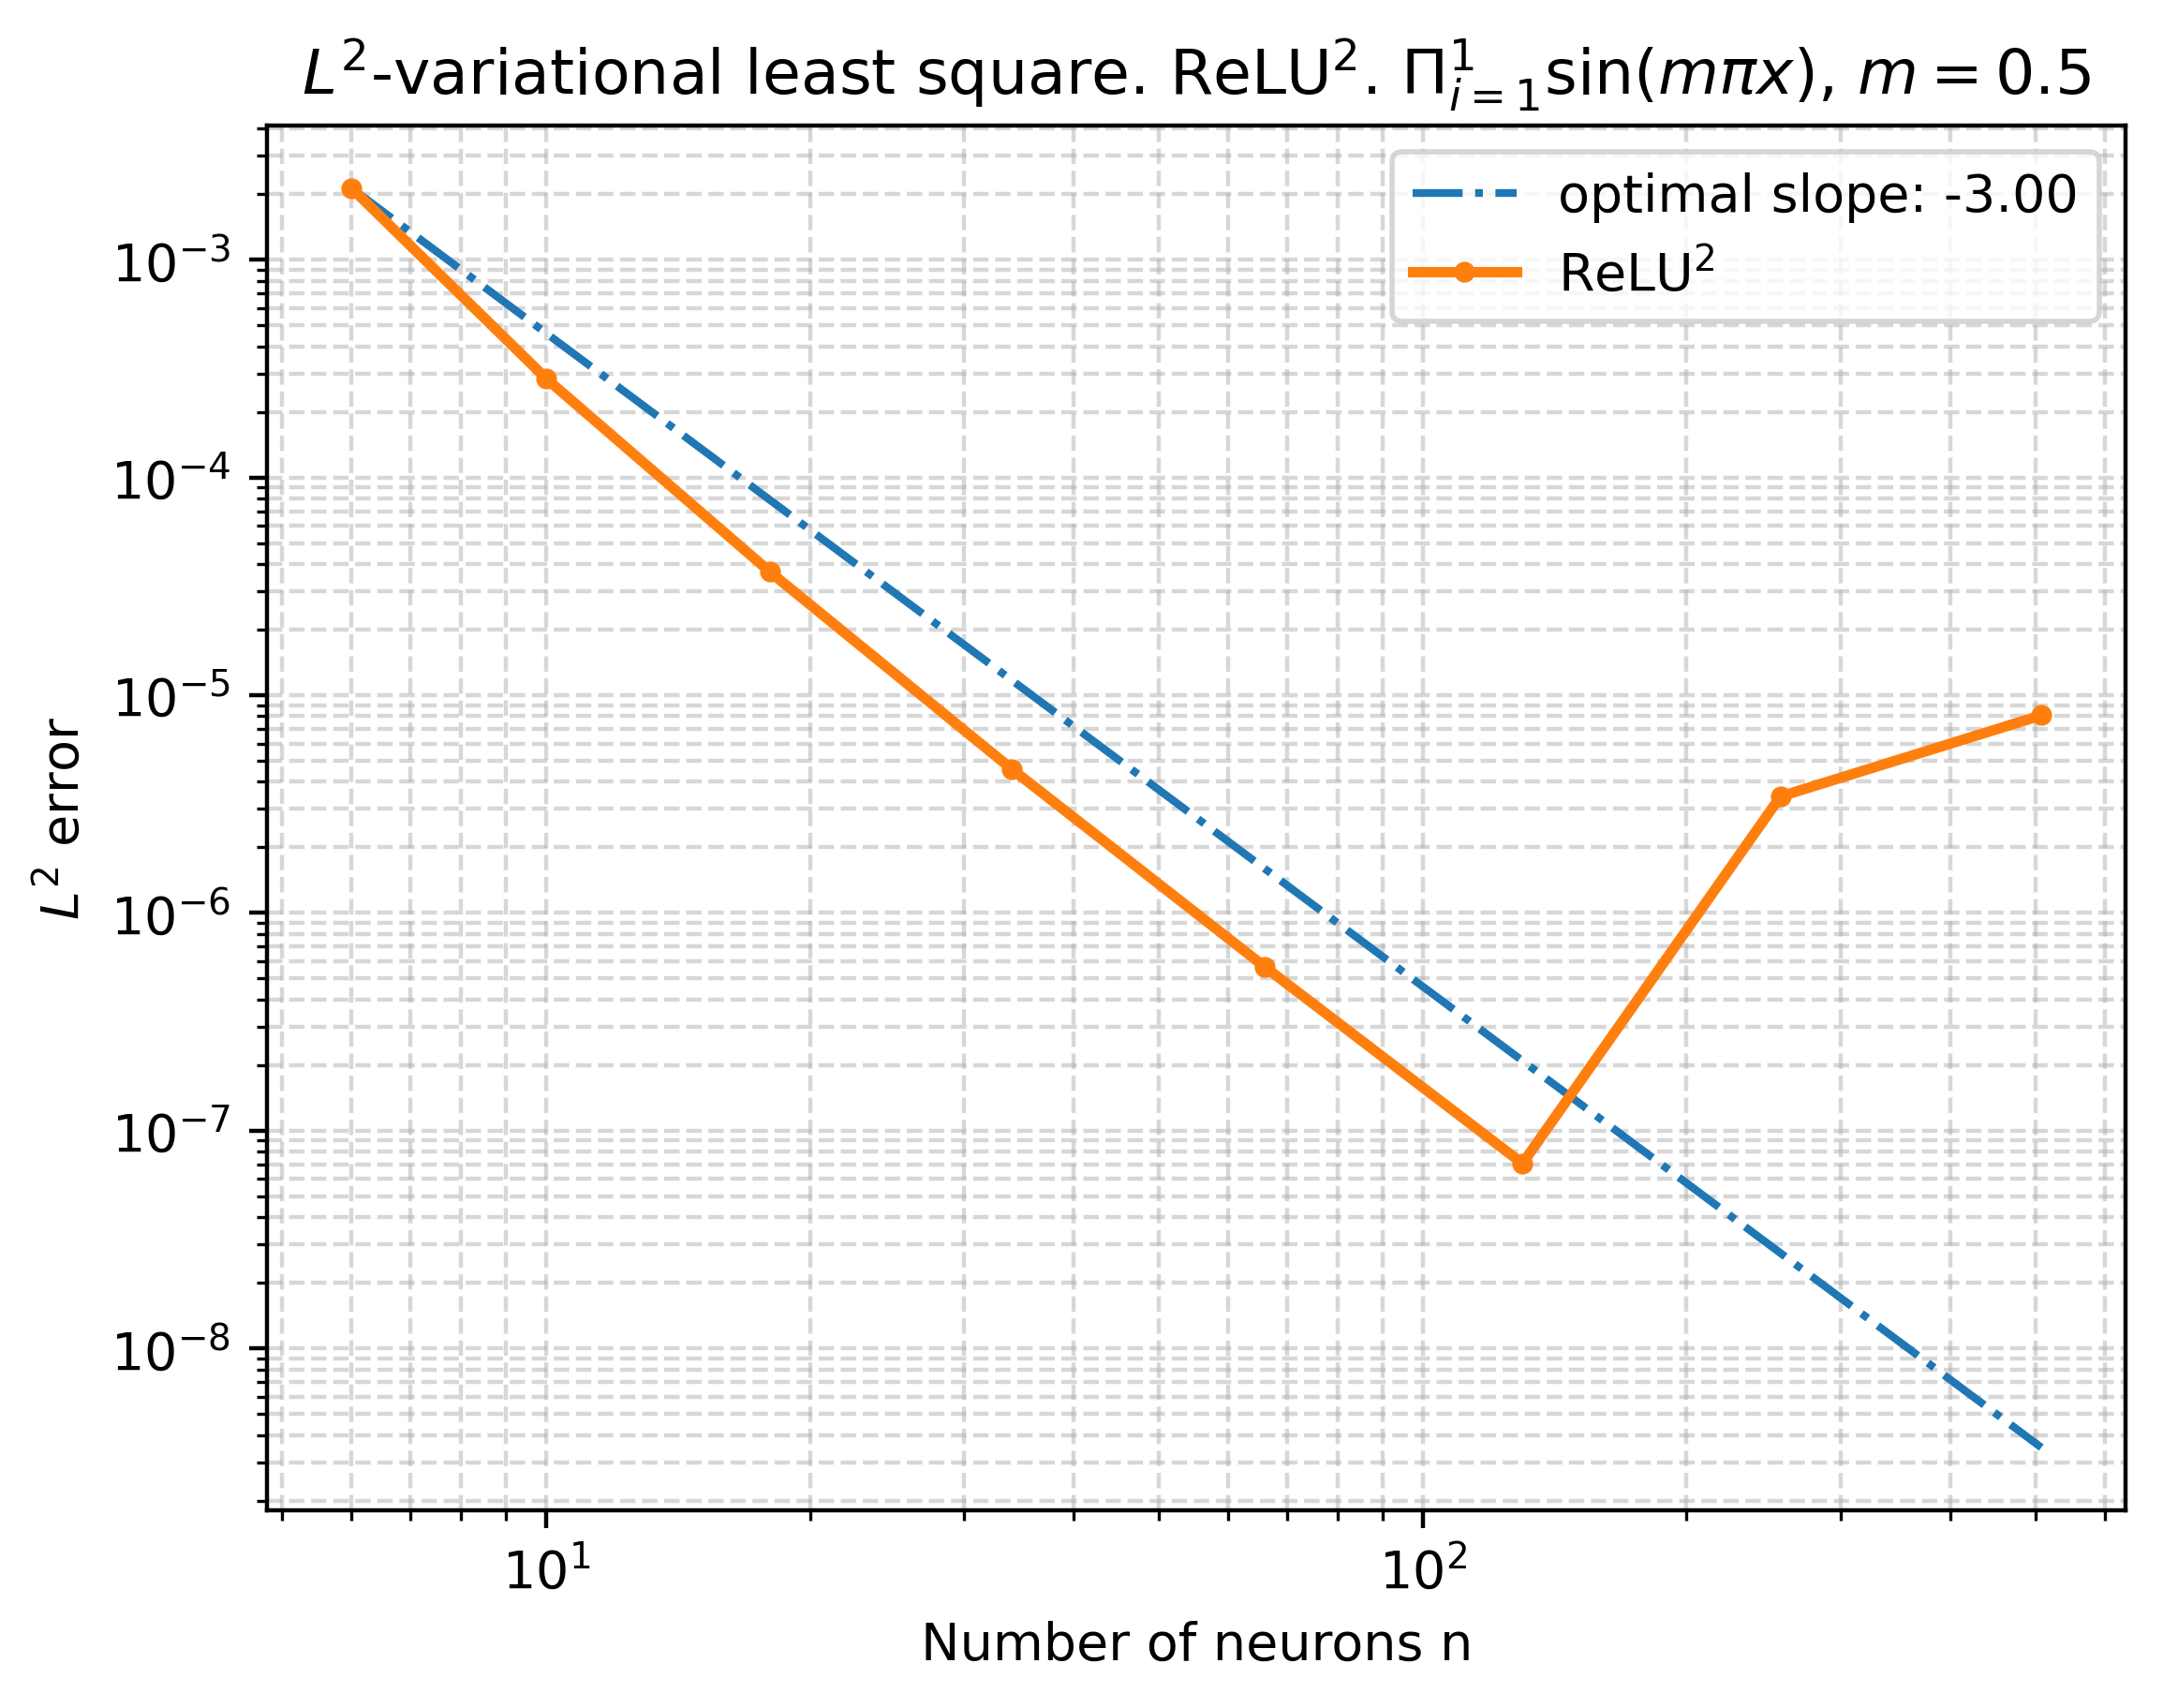

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
6 		 & 2.128e-03 &		 *  \\ \hline  

10 		 &  2.847e-04 &  		 3.94  \\ \hline  

18 		 &  3.685e-05 &  		 3.48  \\ \hline  

34 		 &  4.568e-06 &  		 3.28  \\ \hline  

66 		 &  5.667e-07 &  		 3.15  \\ \hline  

130 		 &  7.065e-08 &  		 3.07  \\ \hline  

256 		 &  3.425e-06 &  		 -5.73  \\ \hline  

508 		 &  8.079e-06 &  		 -1.25  \\ \hline  



In [ ]:


d = 1 
relu_k = 2  

Nx = 1024 
order = 3 
x_l, x_r = -1, 1
integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order)
M = integration_points.size(0)
# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(3,11)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    # my_model = initialize_model_3(my_model).to(device)
    my_model = initialize_model_1d(my_model.cpu()).to(device)
    
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    # sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    sol = minimize_linear_layer_least_square(my_model,u_exact,integration_weights, integration_points,solver="direct")
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**29
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())
actual_neuron_arr = np.array(actual_neuron_list)
mean_err_l2_arr_2 = np.array(err_list_l2)
if relu_k == 1:
    title =f"$L^2$-variational least square. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
else:
    title = f"$L^2$-variational least square. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)

# # save the results
# folder = 'results_relu/'
# os.makedirs(folder, exist_ok=True)
# np.savez(f'{folder}L2VariationalLeastSquare-{d}d-relu{relu_k}.npz', actual_neuron_arr=actual_neuron_arr, mean_err_l2_arr_2=mean_err_l2_arr_2)



### test the lstsq truncated svd 

Number of neurons removed:  2
Number of neurons left:  6
L2 error:  tensor(0.0021)
Number of neurons removed:  6
Number of neurons left:  10
L2 error:  tensor(0.0003)
Number of neurons removed:  14
Number of neurons left:  18
L2 error:  tensor(3.6846e-05)
Number of neurons removed:  30
Number of neurons left:  34
L2 error:  tensor(0.0003)
Number of neurons removed:  62
Number of neurons left:  66
L2 error:  tensor(7.6191e-05)
Number of neurons removed:  126
Number of neurons left:  130
L2 error:  tensor(1.5943e-05)
Number of neurons removed:  256
Number of neurons left:  256
L2 error:  tensor(1.9456e-05)
Number of neurons removed:  516
Number of neurons left:  508
L2 error:  tensor(2.3056e-05)


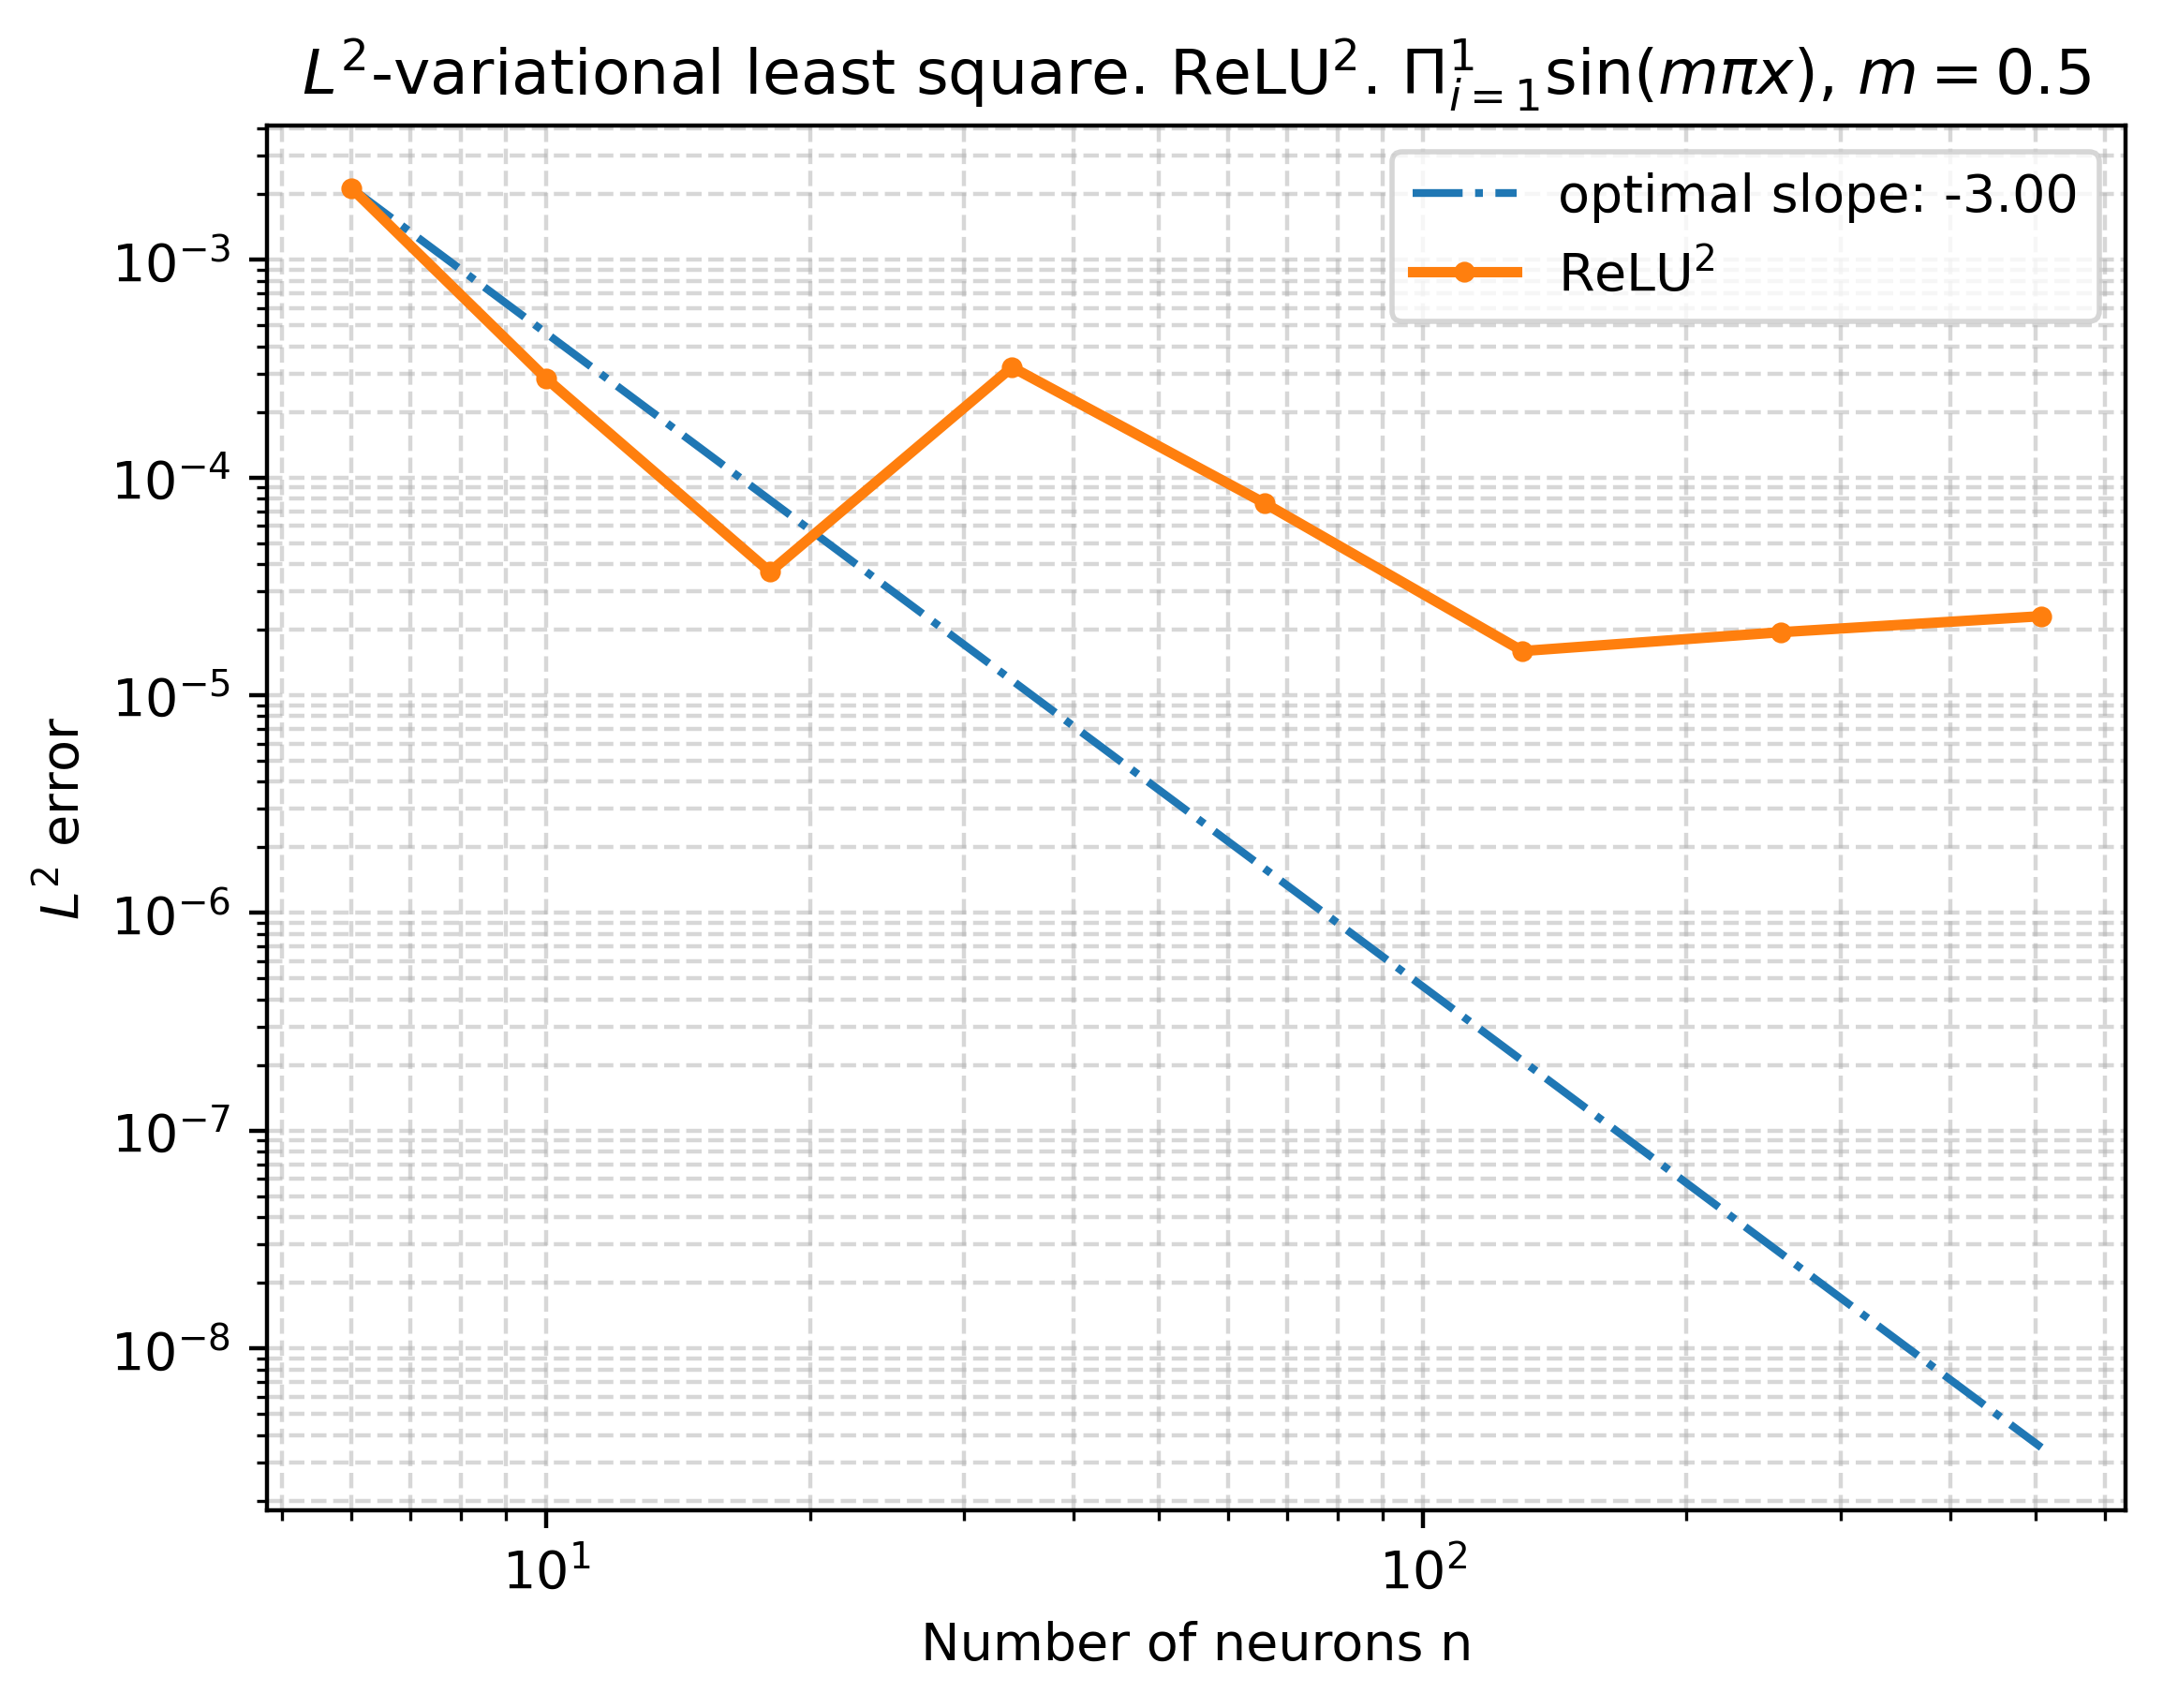

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
6 		 & 2.128e-03 &		 *  \\ \hline  

10 		 &  2.847e-04 &  		 3.94  \\ \hline  

18 		 &  3.685e-05 &  		 3.48  \\ \hline  

34 		 &  3.208e-04 &  		 -3.40  \\ \hline  

66 		 &  7.619e-05 &  		 2.17  \\ \hline  

130 		 &  1.594e-05 &  		 2.31  \\ \hline  

256 		 &  1.946e-05 &  		 -0.29  \\ \hline  

508 		 &  2.306e-05 &  		 -0.25  \\ \hline  

Number of neurons removed:  2
Number of neurons left:  6
L2 error:  tensor(0.0021)
Number of neurons removed:  6
Number of neurons left:  10
L2 error:  tensor(0.0003)
Number of neurons removed:  14
Number of neurons left:  18
L2 error:  tensor(3.6846e-05)
Number of neurons removed:  30
Number of neurons left:  34
L2 error:  tensor(4.5680e-06)
Number of neurons removed:  62
Number of neurons left:  66
L2 error:  tensor(6.0554e-05)
Number of neurons removed:  126
Number of neurons left:  130
L2 error:  tensor(1.1062e-05)
Number of neurons removed:  256
Number of neurons left:  256
L2 erro

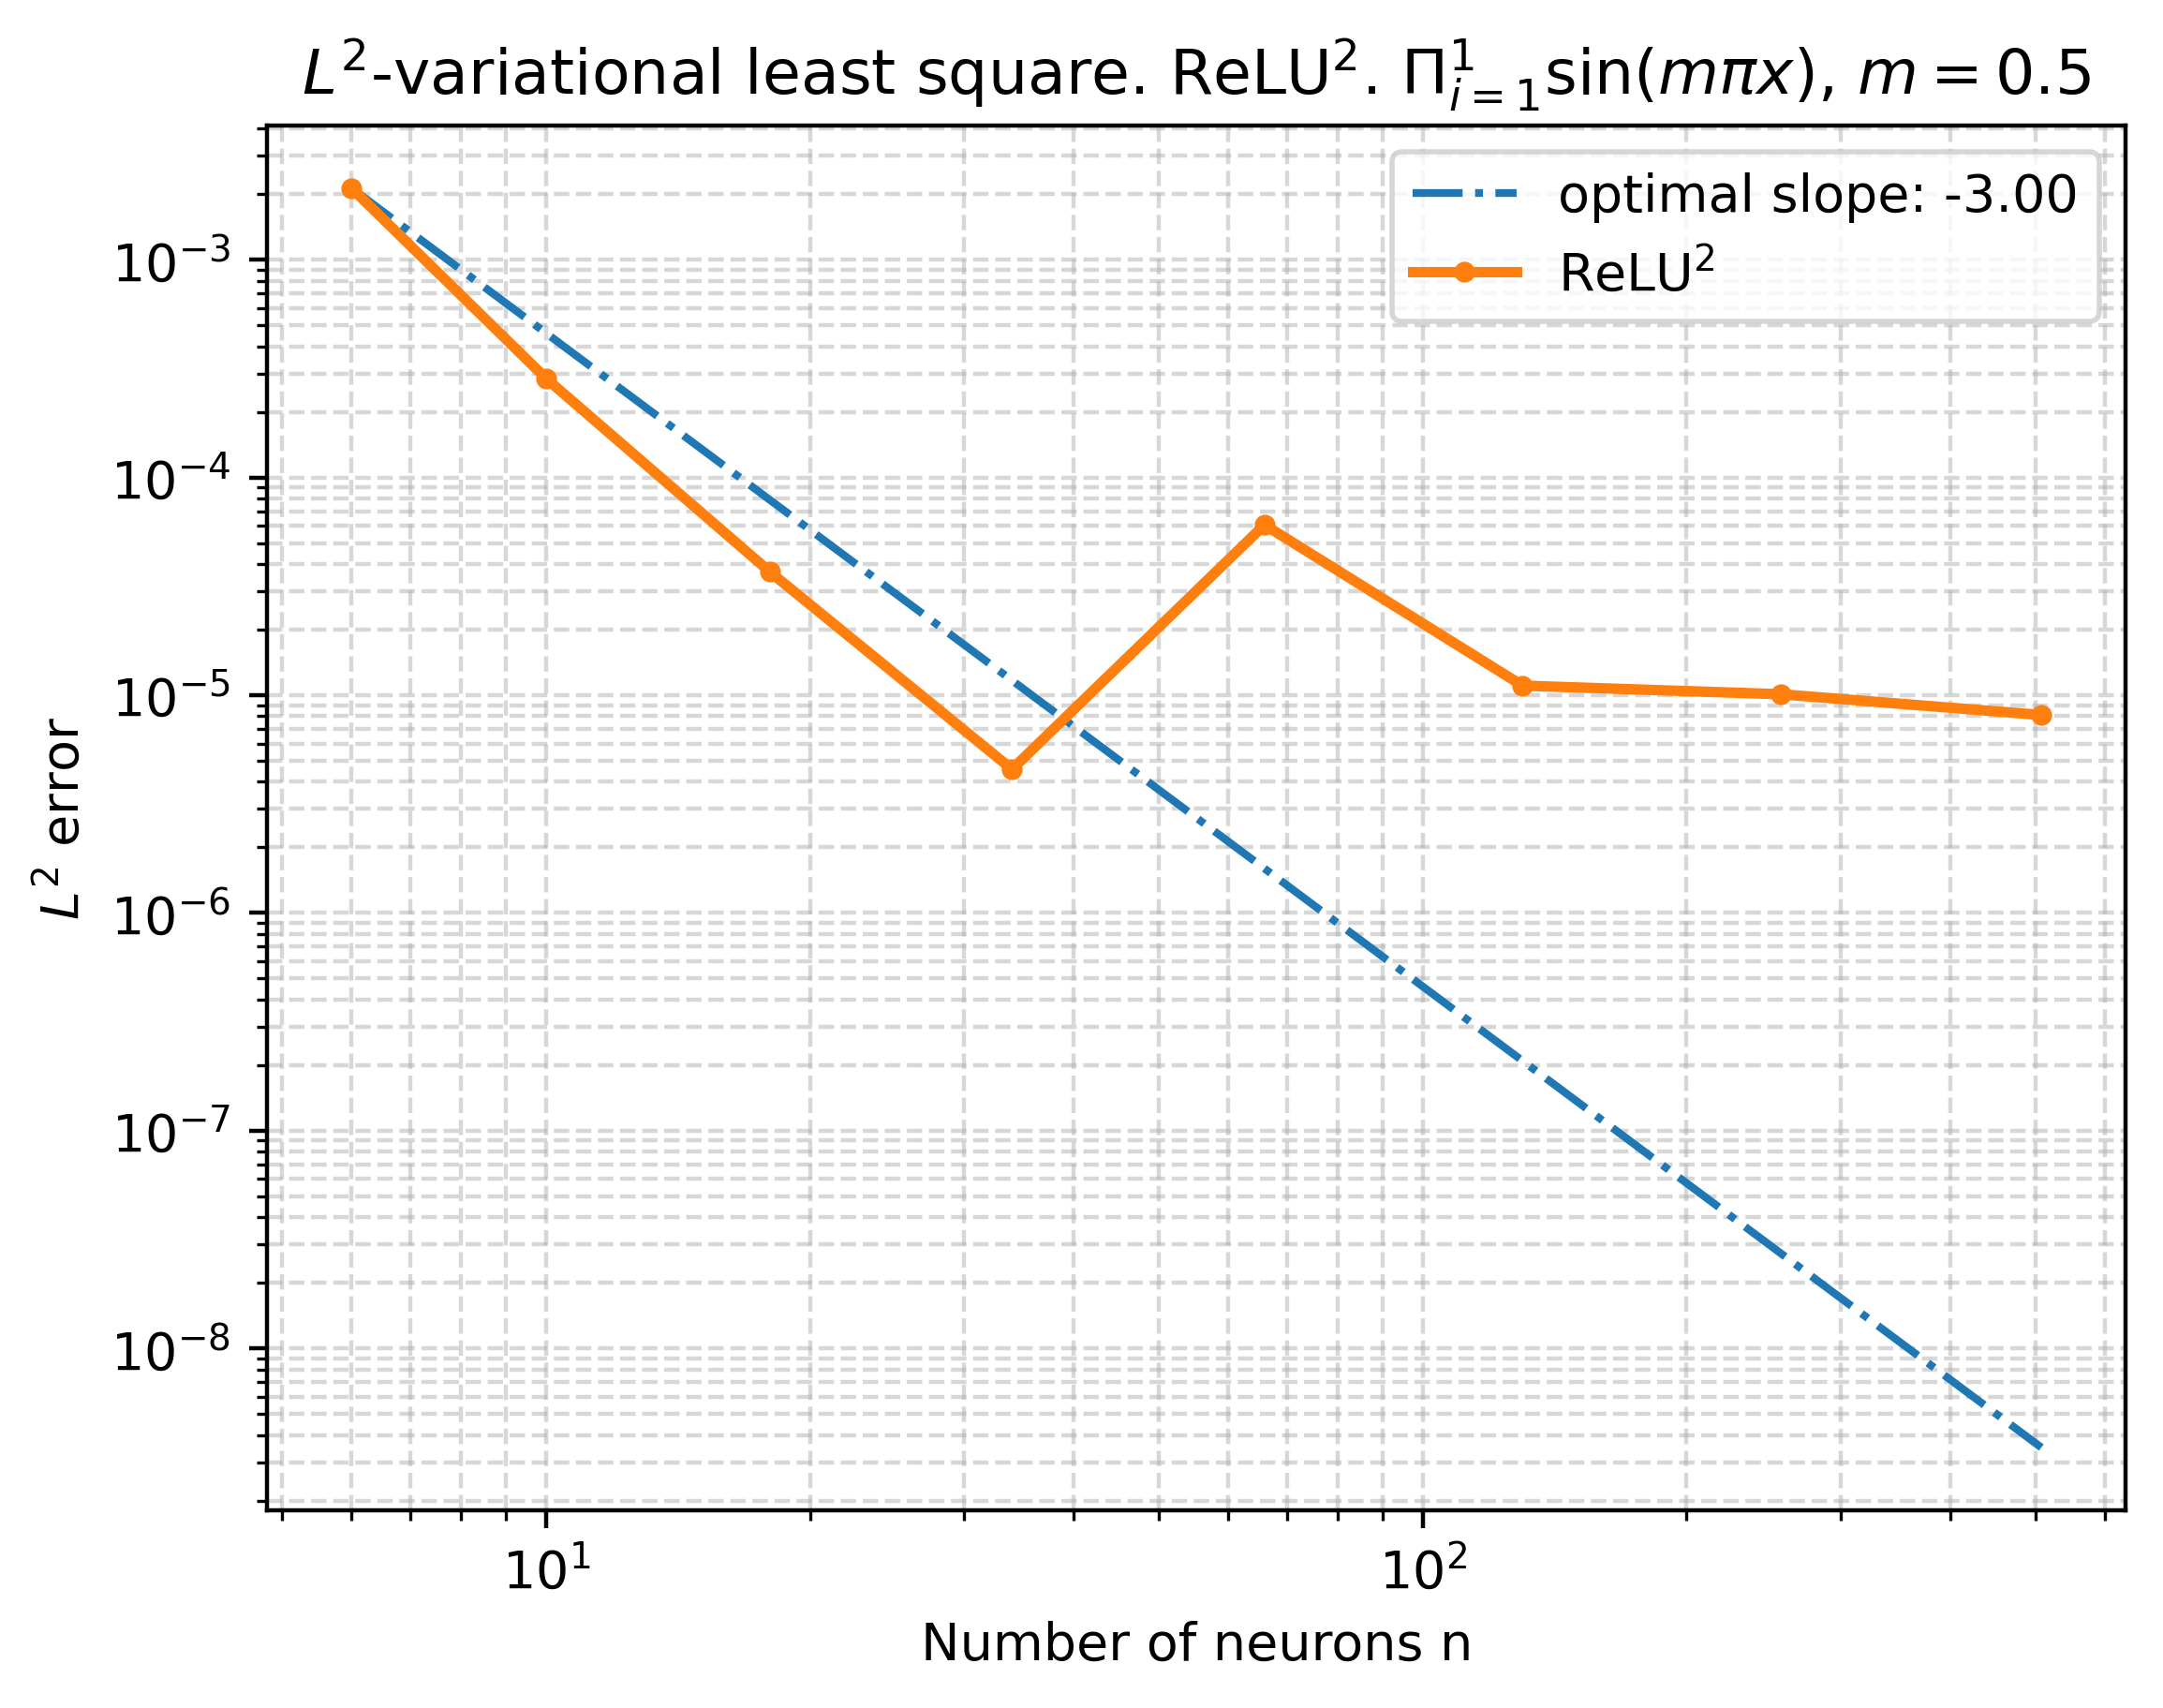

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
6 		 & 2.128e-03 &		 *  \\ \hline  

10 		 &  2.847e-04 &  		 3.94  \\ \hline  

18 		 &  3.685e-05 &  		 3.48  \\ \hline  

34 		 &  4.568e-06 &  		 3.28  \\ \hline  

66 		 &  6.055e-05 &  		 -3.90  \\ \hline  

130 		 &  1.106e-05 &  		 2.51  \\ \hline  

256 		 &  1.010e-05 &  		 0.13  \\ \hline  

508 		 &  8.108e-06 &  		 0.32  \\ \hline  

Number of neurons removed:  2
Number of neurons left:  6
L2 error:  tensor(0.0021)
Number of neurons removed:  6
Number of neurons left:  10
L2 error:  tensor(0.0003)
Number of neurons removed:  14
Number of neurons left:  18
L2 error:  tensor(3.6846e-05)
Number of neurons removed:  30
Number of neurons left:  34
L2 error:  tensor(4.5680e-06)
Number of neurons removed:  62
Number of neurons left:  66
L2 error:  tensor(5.6672e-07)
Number of neurons removed:  126
Number of neurons left:  130
L2 error:  tensor(7.0653e-08)
Number of neurons removed:  256
Number of neurons left:  256
L2 error:

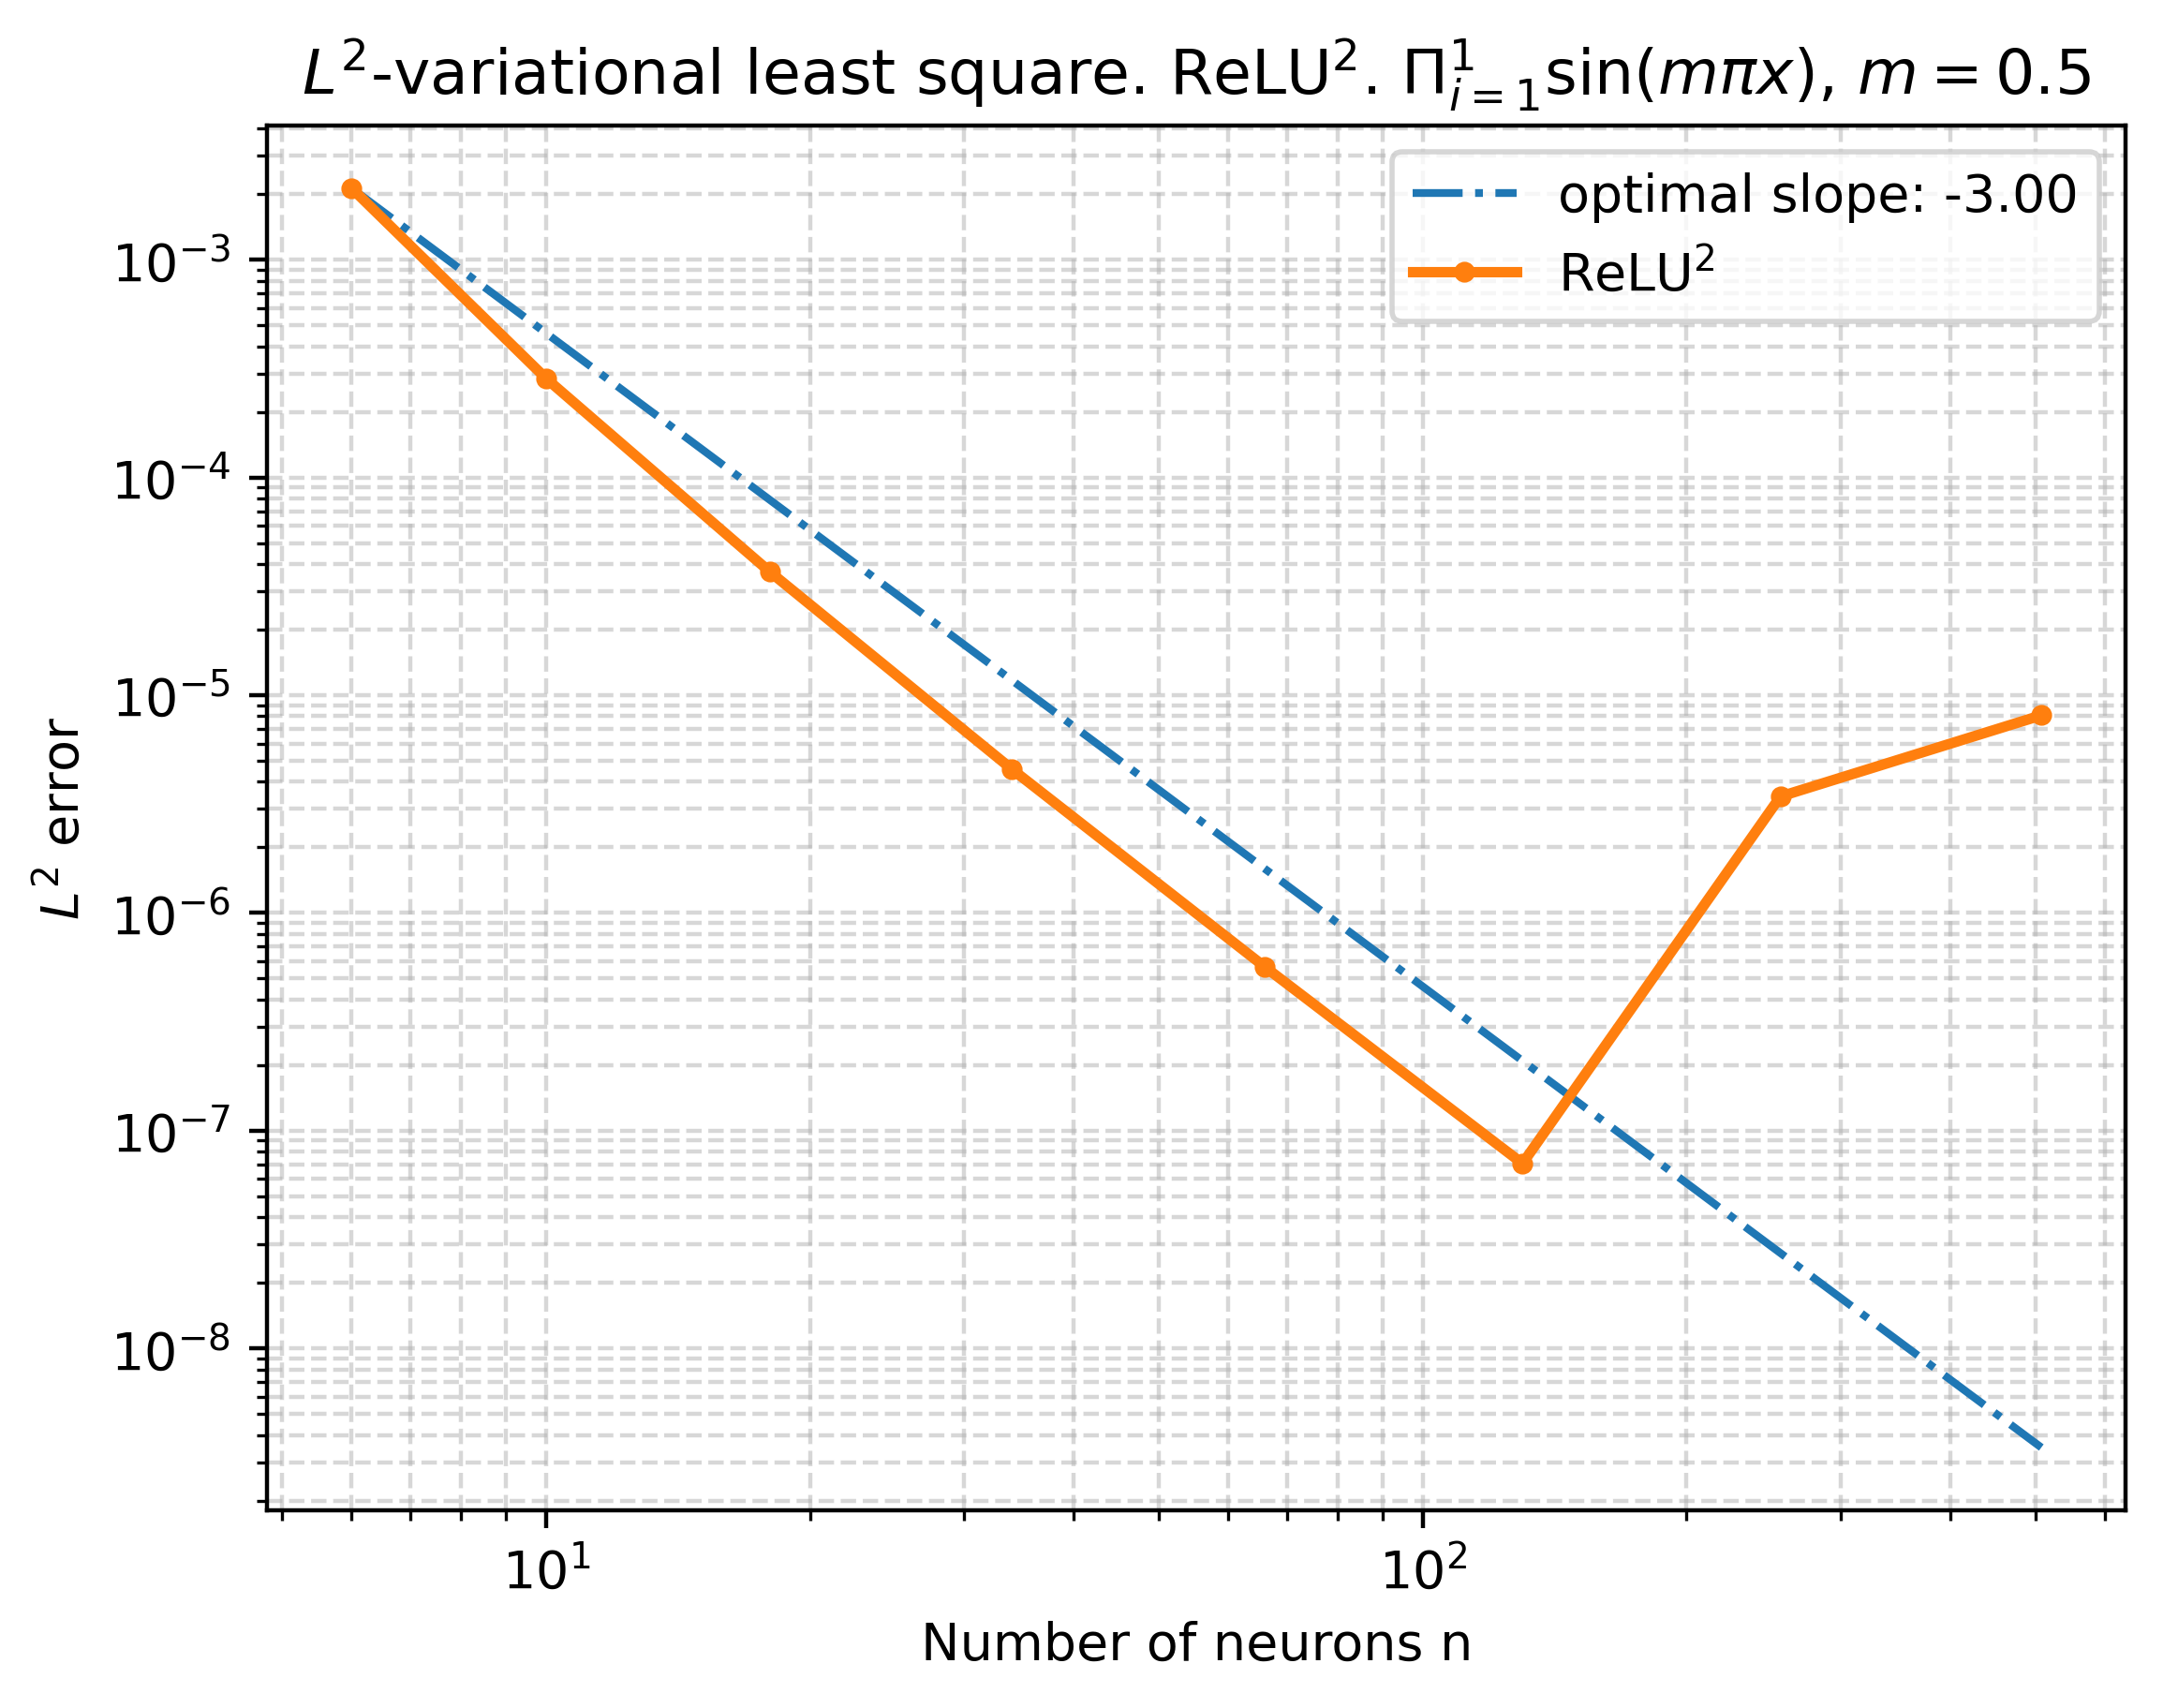

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
6 		 & 2.128e-03 &		 *  \\ \hline  

10 		 &  2.847e-04 &  		 3.94  \\ \hline  

18 		 &  3.685e-05 &  		 3.48  \\ \hline  

34 		 &  4.568e-06 &  		 3.28  \\ \hline  

66 		 &  5.667e-07 &  		 3.15  \\ \hline  

130 		 &  7.065e-08 &  		 3.07  \\ \hline  

256 		 &  3.425e-06 &  		 -5.73  \\ \hline  

508 		 &  8.079e-06 &  		 -1.25  \\ \hline  

Number of neurons removed:  2
Number of neurons left:  6
L2 error:  tensor(0.0021)
Number of neurons removed:  6
Number of neurons left:  10
L2 error:  tensor(0.0003)
Number of neurons removed:  14
Number of neurons left:  18
L2 error:  tensor(3.6846e-05)
Number of neurons removed:  30
Number of neurons left:  34
L2 error:  tensor(4.5680e-06)
Number of neurons removed:  62
Number of neurons left:  66
L2 error:  tensor(5.6672e-07)
Number of neurons removed:  126
Number of neurons left:  130
L2 error:  tensor(7.0653e-08)
Number of neurons removed:  256
Number of neurons left:  256
L2 error

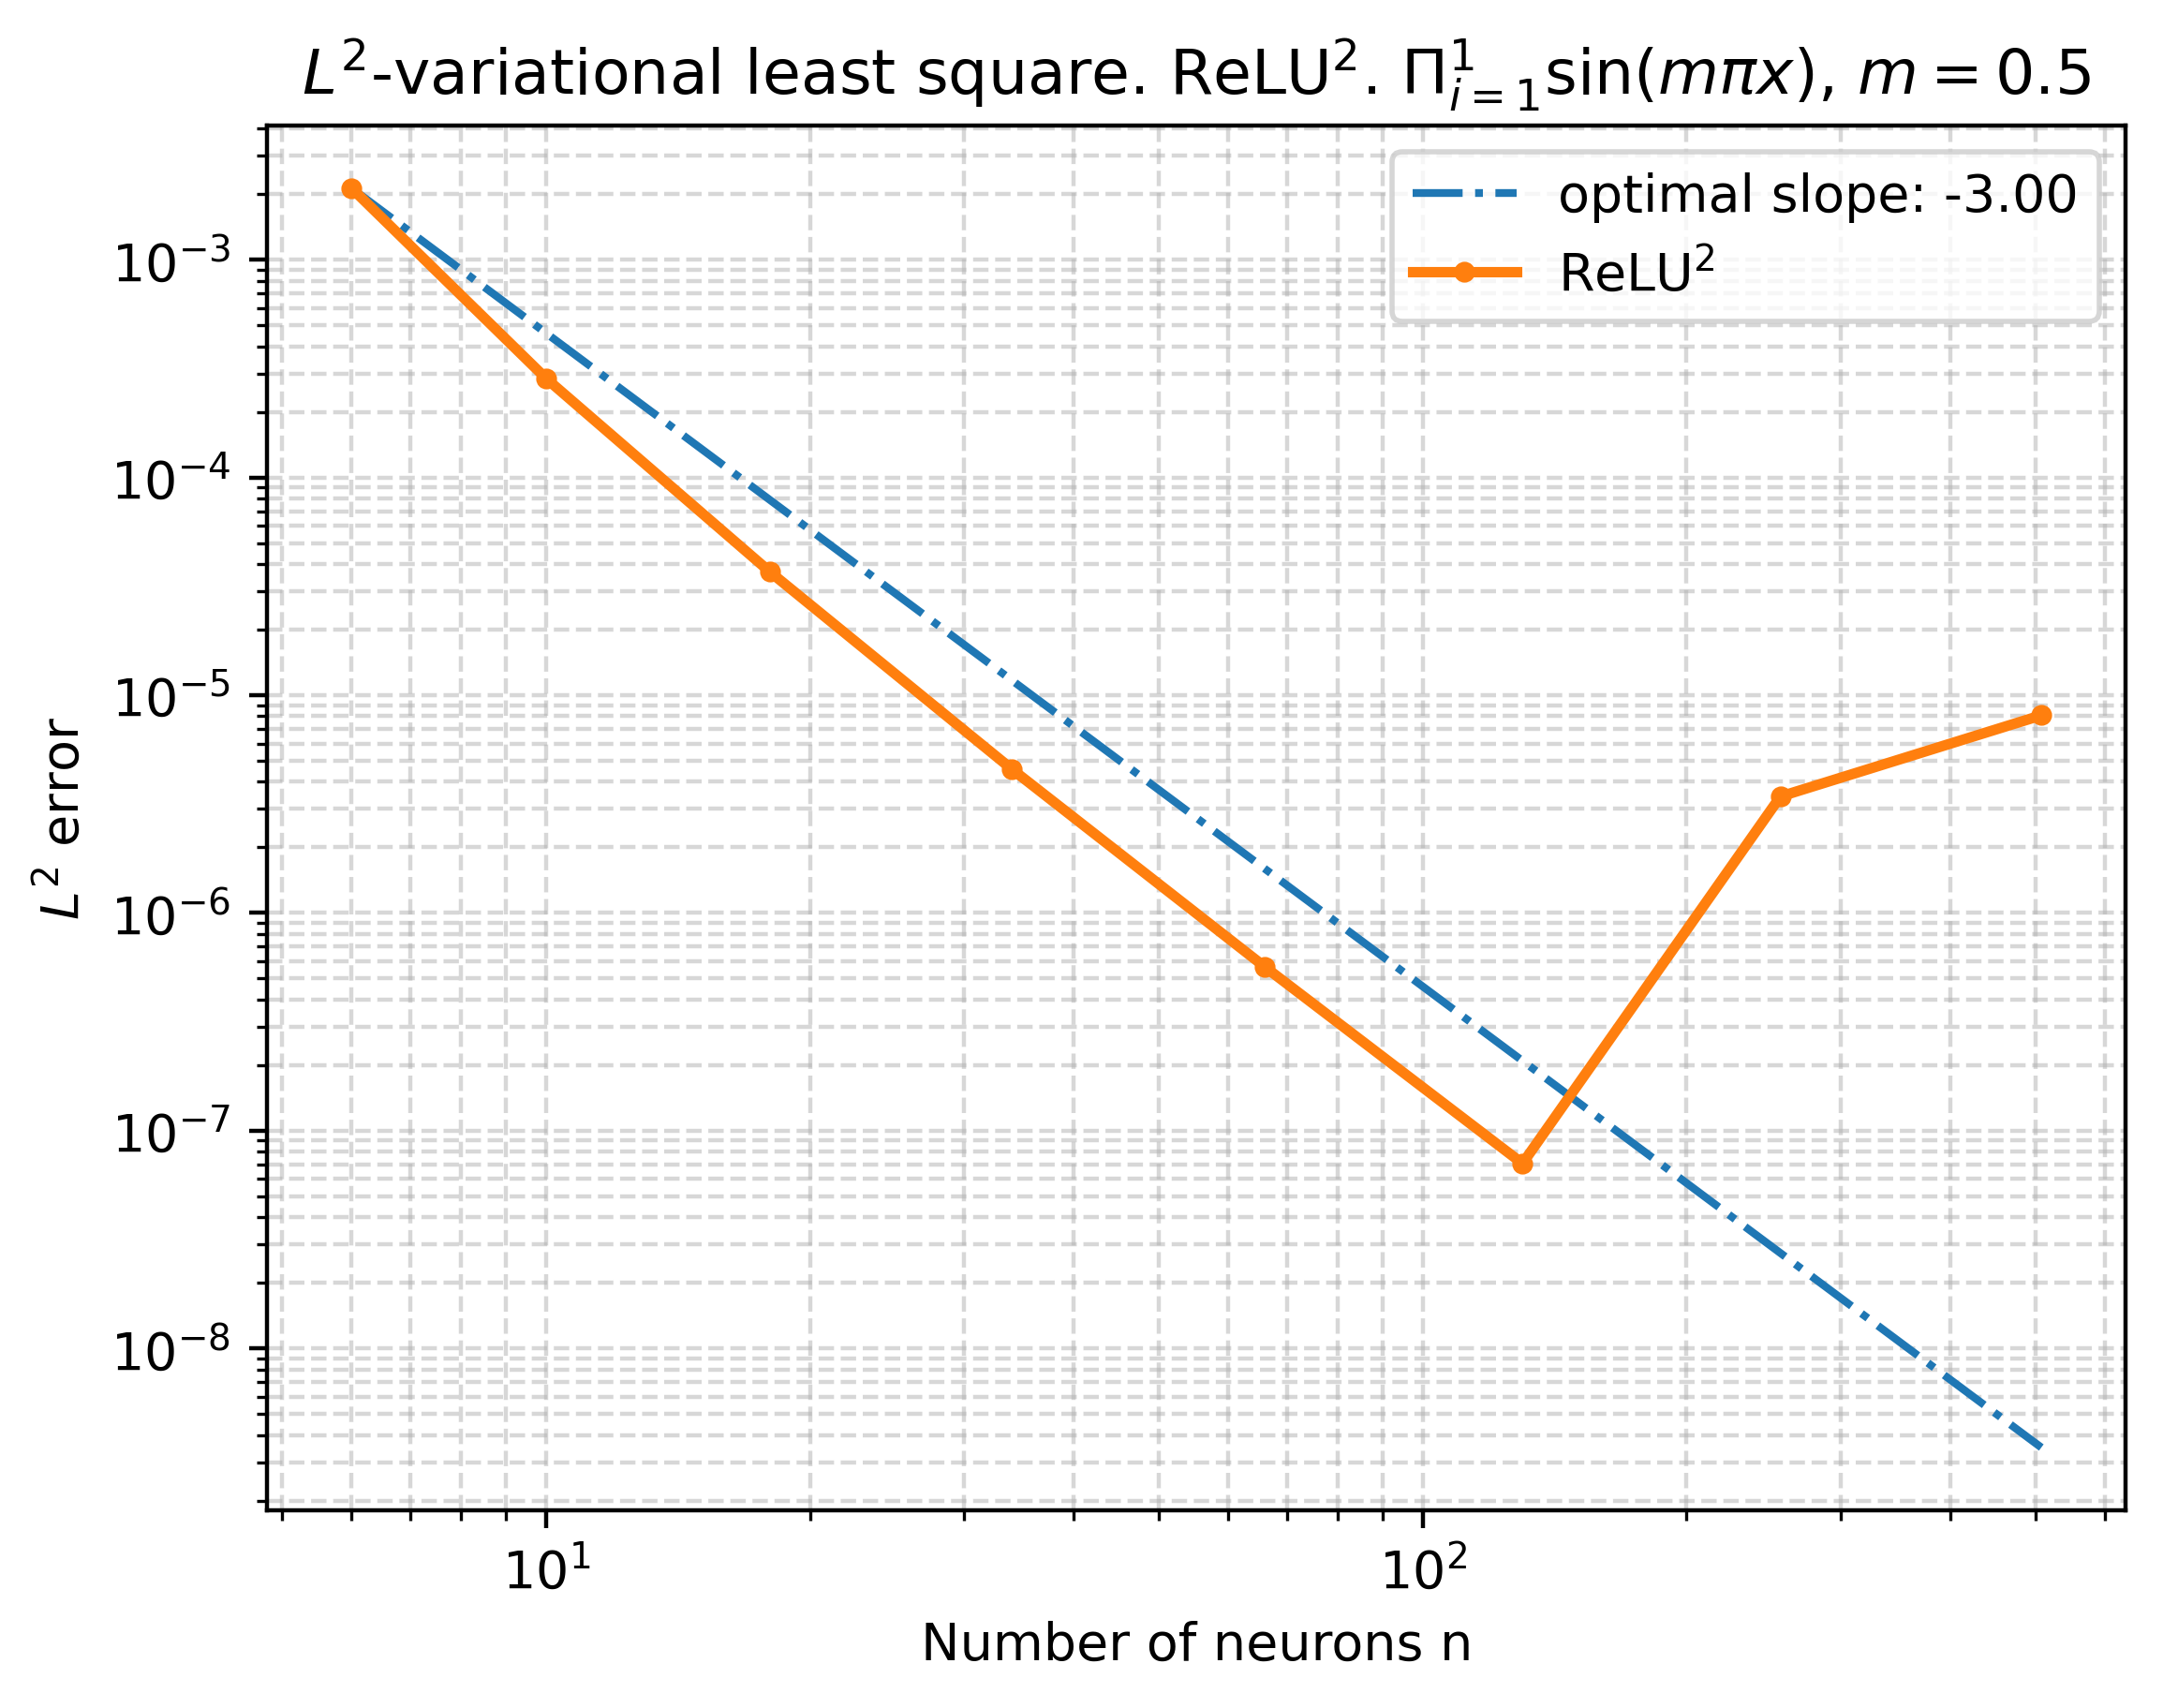

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
6 		 & 2.128e-03 &		 *  \\ \hline  

10 		 &  2.847e-04 &  		 3.94  \\ \hline  

18 		 &  3.685e-05 &  		 3.48  \\ \hline  

34 		 &  4.568e-06 &  		 3.28  \\ \hline  

66 		 &  5.667e-07 &  		 3.15  \\ \hline  

130 		 &  7.065e-08 &  		 3.07  \\ \hline  

256 		 &  3.425e-06 &  		 -5.73  \\ \hline  

508 		 &  8.079e-06 &  		 -1.25  \\ \hline  

Number of neurons removed:  2
Number of neurons left:  6
L2 error:  tensor(0.0021)
Number of neurons removed:  6
Number of neurons left:  10
L2 error:  tensor(0.0003)
Number of neurons removed:  14
Number of neurons left:  18
L2 error:  tensor(3.6846e-05)
Number of neurons removed:  30
Number of neurons left:  34
L2 error:  tensor(4.5680e-06)
Number of neurons removed:  62
Number of neurons left:  66
L2 error:  tensor(5.6672e-07)
Number of neurons removed:  126
Number of neurons left:  130
L2 error:  tensor(7.0653e-08)
Number of neurons removed:  256
Number of neurons left:  256
L2 error

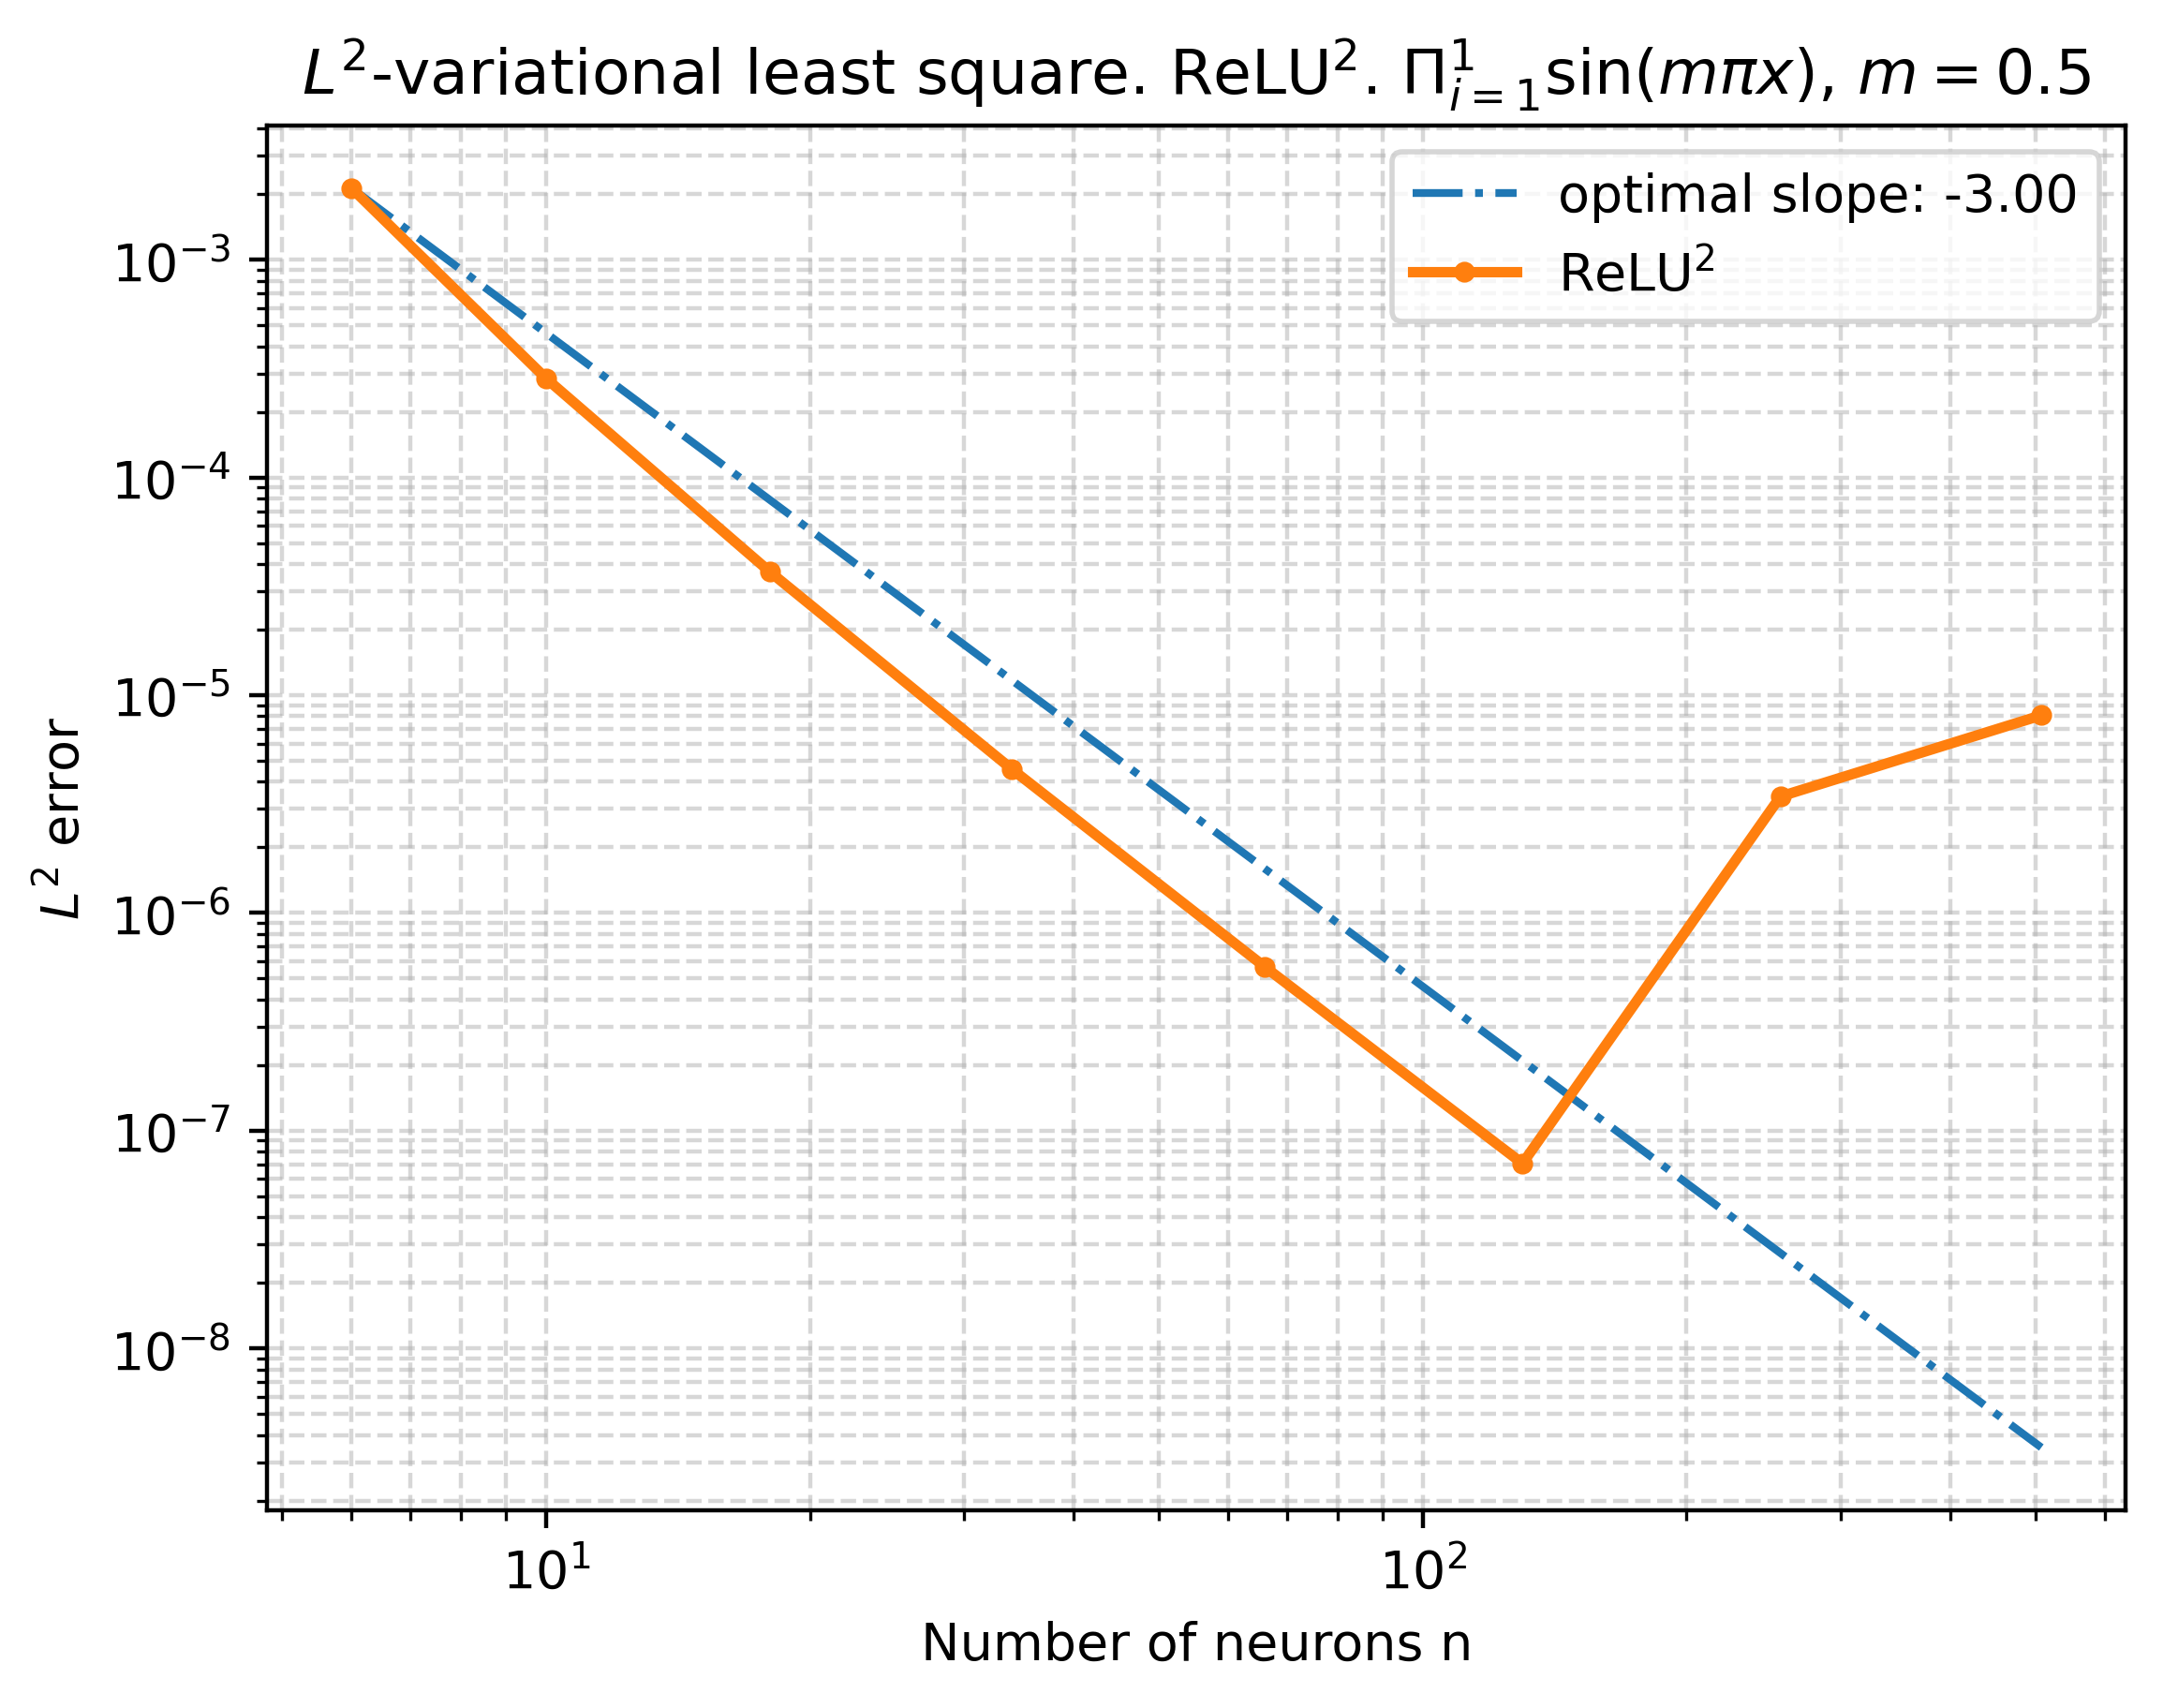

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
6 		 & 2.128e-03 &		 *  \\ \hline  

10 		 &  2.847e-04 &  		 3.94  \\ \hline  

18 		 &  3.685e-05 &  		 3.48  \\ \hline  

34 		 &  4.568e-06 &  		 3.28  \\ \hline  

66 		 &  5.667e-07 &  		 3.15  \\ \hline  

130 		 &  7.065e-08 &  		 3.07  \\ \hline  

256 		 &  3.425e-06 &  		 -5.73  \\ \hline  

508 		 &  8.079e-06 &  		 -1.25  \\ \hline  



In [ ]:
for cond in [1e-6,1e-8,1e-10,1e-12,1e-14]:
    Nx = 2048
    order = 3 
    x_l, x_r = -1, 1
    integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order)
    M = integration_points.size(0)
    # neuron_num_list = [25,50,100,200,400,800,1600]
    neuron_num_arr= np.array([2**i for i in range(3,11)]) 
    actual_neuron_list = []
    err_list_l2 = []
    err_list_h1 = []
    for neuron_num in neuron_num_arr: 
        my_model = model(d,neuron_num,1,relu_k).to(device)
        # my_model = initialize_model_3(my_model).to(device)
        my_model = initialize_model_1d(my_model.cpu()).to(device)
        
        my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
        solver = 'direct'
        # sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
        sol = minimize_linear_layer_least_square(my_model,u_exact,integration_weights, integration_points,solver="direct",cond = cond)
        my_model.fc2.weight.data[0,:] = sol[:] 
        actual_neuron_list.append(my_model.fc1.bias.size(0)) 
        # compute the error 
    #     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
        memory = 2**29
        num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
        total_size2 = M*(num_neuron+1)
        num_batch2 = total_size2//memory + 1 
        batch_size_2 = M//num_batch2 # in
        errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

        print("L2 error: ",errl2)

        err_list_l2.append(errl2.item())
    actual_neuron_arr = np.array(actual_neuron_list)
    mean_err_l2_arr_2 = np.array(err_list_l2)
    if relu_k == 1:
        title =f"$L^2$-variational least square. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    else:
        title = f"$L^2$-variational least square. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
    plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
    output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)

    # # save the results
    # folder = 'results_relu/'
    # os.makedirs(folder, exist_ok=True)
    # np.savez(f'{folder}L2VariationalLeastSquare-{d}d-relu{relu_k}.npz', actual_neuron_arr=actual_neuron_arr, mean_err_l2_arr_2=mean_err_l2_arr_2)



## Solve Ma = b 

In [15]:

d = 1 
relu_k = 2  

Nx = 1024 
order = 3   
x_l, x_r = -1, 1
integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order)
M = integration_points.size(0)
# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(3,11)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    # my_model = initialize_model_3(my_model).to(device)
    my_model = initialize_model_1d(my_model.cpu()).to(device)
    
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    # compute the error 
#     errl2 = (integration_weights.t()@(u_exact(integration_points) - my_model(integration_points).detach())**2)**0.5
    memory = 2**29
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 # in
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)

    print("L2 error: ",errl2)

    err_list_l2.append(errl2.item())
actual_neuron_arr = np.array(actual_neuron_list)
mean_err_l2_arr_2 = np.array(err_list_l2)
# if relu_k == 1:
#     title =f"$L^2$-minimization. ReLU. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
# else:
#     title = f"$L^2$-minimization. ReLU$^{relu_k}$. $\Pi_{{i = 1}}^{d}\sin(m \pi x)$, $m = {m}$"
# plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr_2,title)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)

# save the results
folder = 'results_relu/'
os.makedirs(folder, exist_ok=True)
np.savez(f'{folder}L2minimization-{d}d-relu{relu_k}.npz', actual_neuron_arr=actual_neuron_arr, mean_err_l2_arr_2=mean_err_l2_arr_2)



Number of neurons removed:  2
Number of neurons left:  6
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.004534006118774414
solving Ax = b time taken:  0.006174802780151367
L2 error:  tensor(0.0021)
Number of neurons removed:  6
Number of neurons left:  10
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.0003170967102050781
solving Ax = b time taken:  7.700920104980469e-05
L2 error:  tensor(0.0003)
Number of neurons removed:  14
Number of neurons left:  18
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.0005068778991699219
solving Ax = b time taken:  6.198883056640625e-05
L2 error:  tensor(3.6856e-05)
Number of neurons removed:  30
Number of neurons left:  34
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.0013718605041503906
solving Ax = b time taken:  0.002240896224975586
L2 error:  tensor(7.5791e-06)
Number of neurons removed:  62
Number of neurons left:  66
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.00234198570251